***

##  MLOPS - PRACTICAL 2

***

## aim:

To perform exploratory data analysis, preprocess categorical features, train Logistic Regression and Random Forest classifiers using a Pipeline, compare their performance, and identify important churn-driving features.

## problem statement:

Given `customer_churn_dummy.csv`, predict customer churn. Perform basic EDA, encode categorical variables, split the data, train Logistic Regression and Random Forest models, calculate evaluation metrics, display the confusion matrix/ROC information, and determine important Random Forest features.

***

## 1. python code

DATASET SHAPE: (2000, 10)

Churn rate by contract type:
contract_type
Month-to-month    0.336
One year          0.161
Two year          0.159
Name: churn, dtype: float64

Churn rate by tech support:
tech_support
No     0.293
Yes    0.210
Name: churn, dtype: float64

Average tenure: churned vs retained:
churn
0    37.5
1    28.5
Name: tenure_months, dtype: float64

MODEL COMPARISON
                     accuracy  precision  recall     f1  roc_auc
Logistic Regression     0.756      0.581   0.194  0.291    0.751
Random Forest           0.754      0.688   0.085  0.152    0.746

TOP CHURN DRIVERS
                          feature  importance
         remainder__tenure_months    0.255886
 remainder__days_since_last_login    0.218797
       remainder__monthly_charges    0.174252
      cat__contract_type_Two year    0.076261
     remainder__num_support_calls    0.061625
            cat__tech_support_Yes    0.056508
      cat__contract_type_One year    0.056215
cat__internet_service_Fiber optic 

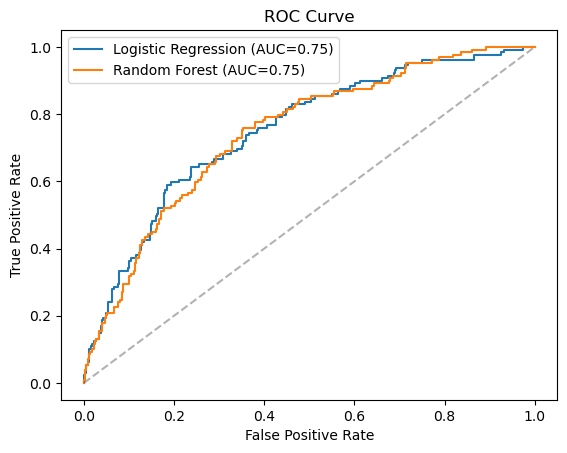


CONFUSION MATRIX
[[366   5]
 [118  11]]


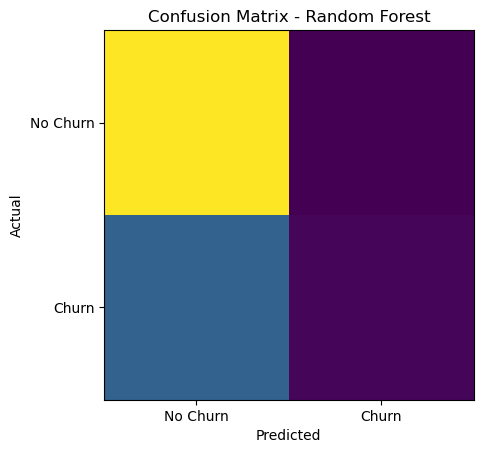

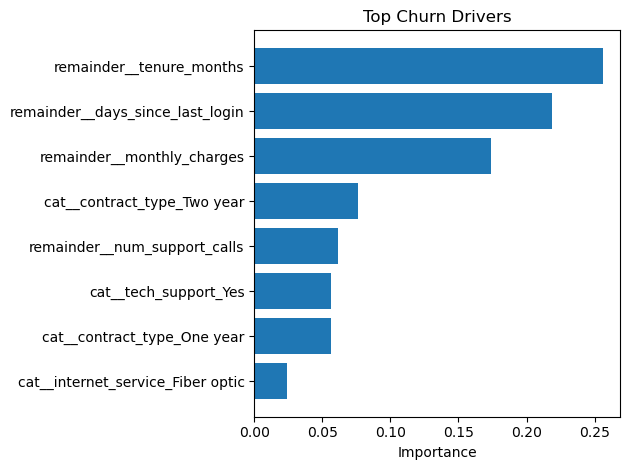

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import ( accuracy_score, precision_score,  recall_score, f1_score,  roc_auc_score, confusion_matrix, roc_curve )

df = pd.read_csv("customer_churn_dummy.csv")

# Quick EDA
print("DATASET SHAPE:", df.shape)

print("\nChurn rate by contract type:")
print(df.groupby("contract_type")["churn"].mean().round(3))

print("\nChurn rate by tech support:")
print(df.groupby("tech_support")["churn"].mean().round(3))

print("\nAverage tenure: churned vs retained:")
print(df.groupby("churn")["tenure_months"].mean().round(1))

# Features and target
target = "churn"

features = [
    "tenure_months",
    "monthly_charges",
    "contract_type",
    "tech_support",
    "internet_service",
    "num_support_calls",
    "payment_method",
    "days_since_last_login"
]

X = df[features]
y = df[target]

categorical = [
    "contract_type",
    "tech_support",
    "internet_service",
    "payment_method"
]

numeric = [
    "tenure_months",
    "monthly_charges",
    "num_support_calls",
    "days_since_last_login"
]

# Preprocessing
preprocessor = ColumnTransformer([ ( "cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical )], remainder="passthrough")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, stratify=y, random_state=42 )

# Models
models = { "Logistic Regression": LogisticRegression(max_iter=1000),
          "Random Forest": RandomForestClassifier( n_estimators=200, max_depth=6, random_state=42 ) }

results = {}

for name, clf in models.items():

    pipe = Pipeline([ ("prep", preprocessor), ("clf", clf) ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "pipeline": pipe,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
        "probs": probs,
        "preds": preds
    }

# Model comparison
comparison = pd.DataFrame({
    name: {
        "accuracy": result["accuracy"],
        "precision": result["precision"],
        "recall": result["recall"],
        "f1": result["f1"],
        "roc_auc": result["roc_auc"]
    }
    for name, result in results.items()
}).T.round(3)

print("\nMODEL COMPARISON")
print(comparison)

# Random Forest feature importance
rf_pipe = results["Random Forest"]["pipeline"]

feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["clf"].feature_importances_

importance_df = pd.DataFrame({ "feature": feature_names,
                              "importance": importances })

importance_df = importance_df.sort_values( "importance", ascending=False).head(8)

print("\nTOP CHURN DRIVERS")
print(importance_df.to_string(index=False))

# ROC curves
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result["probs"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={result['roc_auc']:.2f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test,results["Random Forest"]["preds"])

print("\nCONFUSION MATRIX")
print(cm)

plt.imshow(cm)
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Feature importance plot
plt.barh( importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top Churn Drivers")
plt.tight_layout()
plt.show()

***

## 2. output

The program displays:

- Dataset shape
- Churn rates by selected categories
- Model comparison containing accuracy, precision, recall, F1 and ROC-AUC
- Top Random Forest feature importances
- ROC curve
- Confusion matrix
- Feature-importance plot

***

## 3. viva questions

1. **Why use One-Hot Encoding?**  
   To convert categorical values into numerical features.

2. **Why use `ColumnTransformer`?**  
   To apply preprocessing to selected columns while leaving other columns unchanged.

3. **Why use a Pipeline?**  
   To combine preprocessing and model training/prediction into one consistent workflow.

4. **What does `handle_unknown="ignore"` do?**  
   It prevents errors when an unseen category appears during transformation.

5. **Why use `drop="first"`?**  
   To remove one category from each encoded variable and avoid redundant dummy variables.

6. **Why use `stratify=y`?**  
   To approximately preserve class proportions in train and test data.

7. **Difference between `predict()` and `predict_proba()`?**  
   `predict()` gives the class; `predict_proba()` gives class probabilities.

8. **What is precision?**  
   Of the samples predicted positive, the proportion that are actually positive.

9. **What is recall?**  
   Of the actual positive samples, the proportion correctly identified.

10. **What is F1-score?**  
    The harmonic mean of precision and recall.

11. **What is ROC-AUC?**  
    A measure of how well the model separates the two classes across thresholds.

12. **What is a confusion matrix?**  
    A table showing TP, TN, FP and FN.

13. **What is `max_depth=6`?**  
    The maximum depth allowed for each Random Forest tree.

14. **Why compare two models?**  
    To determine which model performs better on the chosen evaluation metrics.

***

## result:

The customer churn dataset is analysed, categorical variables are encoded, both classifiers are trained through a common preprocessing pipeline, their performance is compared, and important churn features are identified using Random Forest.

## observation:

The customer churn data was analysed and the categorical variables were encoded before model training. Logistic Regression and Random Forest were evaluated using classification metrics, and Random Forest feature importance was used to identify the most influential features for churn prediction.

***